## Homework

In [1]:
!mkdir -p data

In [2]:
data_url = "https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip"
!wget $data_url -O data/HairType.zip


--2025-12-01 12:38:25--  https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/405934815/e712cf72-f851-44e0-9c05-e711624af985?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-01T13%3A19%3A30Z&rscd=attachment%3B+filename%3Ddata.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-01T12%3A19%3A14Z&ske=2025-12-01T13%3A19%3A30Z&sks=b&skv=2018-11-09&sig=olcwh2nRRmZqWNUBcw0jP3xe17GeJrJmDid3uH98emY%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NDU5NDUwNSwibmJmIjoxNzY0NTkyNzA1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG

In [3]:
!unzip data/HairType.zip -d data/HairType


Archive:  data/HairType.zip
   creating: data/HairType/data/
   creating: data/HairType/data/test/
   creating: data/HairType/data/test/curly/
  inflating: data/HairType/data/test/curly/03312ac556a7d003f7570657f80392c34.jpg  
  inflating: data/HairType/data/test/curly/106dfcf4abe76990b585b2fc2e3c9f884.jpg  
  inflating: data/HairType/data/test/curly/1a9dbe23a0d95f1c292625960e4509184.jpg  
  inflating: data/HairType/data/test/curly/341ea26e6677b655f8447af56073204a4.jpg  
  inflating: data/HairType/data/test/curly/61aPFVrm42L._SL1352_.jpg  
  inflating: data/HairType/data/test/curly/6d8acb0fe980774ea4e5631198587f45.png  
  inflating: data/HairType/data/test/curly/7f5649a0c33a2b334f23221a52c16b9b.jpg  
  inflating: data/HairType/data/test/curly/90146673.jpg  
  inflating: data/HairType/data/test/curly/9b3608e01d78fbabc9fb0719323d507f4.jpg  
  inflating: data/HairType/data/test/curly/b171c99161f3cffc12d4b74488ef2fc6.jpg  
  inflating: data/HairType/data/test/curly/blogger_one.jpg  
  infla

In [4]:
import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

**Imports**

In [5]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

In [6]:
DATA_DIR = "../content/data/HairType/data"
DATA_DIR

'../content/data/HairType/data'

In [7]:
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TRAIN_DIR

'../content/data/HairType/data/train'

In [8]:
TEST_DIR = os.path.join(DATA_DIR, "test")
TEST_DIR

'../content/data/HairType/data/test'

In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor()
])

In [10]:
train_transforms

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

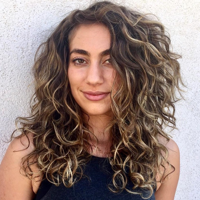

In [11]:
img = Image.open(f"{TRAIN_DIR}/curly/13-long-curly-haircut-BclM5gMly7s.jpg")
img.resize((200, 200))

In [12]:
x = train_transforms(img)
x

tensor([[[0.9608, 0.9765, 0.9765,  ..., 0.9922, 0.9922, 0.9922],
         [0.9529, 0.9373, 0.9373,  ..., 0.9882, 0.9882, 0.9882],
         [0.9647, 0.9569, 0.9529,  ..., 0.9686, 0.9686, 0.9490],
         ...,
         [0.7765, 0.7804, 0.8000,  ..., 0.8392, 0.8314, 0.8549],
         [0.7765, 0.7686, 0.7922,  ..., 0.8627, 0.8549, 0.8392],
         [0.7765, 0.7882, 0.7922,  ..., 0.8392, 0.8510, 0.8431]],

        [[0.9529, 0.9686, 0.9686,  ..., 0.9882, 0.9882, 0.9882],
         [0.9451, 0.9294, 0.9294,  ..., 0.9843, 0.9882, 0.9843],
         [0.9569, 0.9490, 0.9451,  ..., 0.9686, 0.9647, 0.9451],
         ...,
         [0.5333, 0.5333, 0.5490,  ..., 0.8510, 0.8431, 0.8588],
         [0.5333, 0.5176, 0.5412,  ..., 0.8745, 0.8706, 0.8510],
         [0.5333, 0.5373, 0.5412,  ..., 0.8549, 0.8706, 0.8627]],

        [[0.9569, 0.9725, 0.9725,  ..., 0.9725, 0.9765, 0.9804],
         [0.9490, 0.9333, 0.9333,  ..., 0.9686, 0.9686, 0.9686],
         [0.9608, 0.9529, 0.9490,  ..., 0.9490, 0.9451, 0.

In [13]:
x.shape

torch.Size([3, 200, 200])

In [14]:
test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor()
])

In [15]:
test_transforms

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

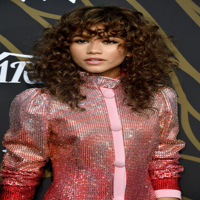

In [16]:
img = Image.open(f"{TEST_DIR}/curly/6d8acb0fe980774ea4e5631198587f45.png")
img.resize((200, 200))

In [17]:
x = train_transforms(img)
x

tensor([[[0.1255, 0.1294, 0.1294,  ..., 0.1294, 0.1333, 0.1412],
         [0.1294, 0.1294, 0.1294,  ..., 0.1333, 0.1333, 0.1412],
         [0.1333, 0.1333, 0.1373,  ..., 0.1373, 0.1373, 0.1373],
         ...,
         [0.2275, 0.2784, 0.3529,  ..., 0.1137, 0.1098, 0.1020],
         [0.2667, 0.3098, 0.3922,  ..., 0.1098, 0.1059, 0.1059],
         [0.2588, 0.2549, 0.3843,  ..., 0.1020, 0.1059, 0.1020]],

        [[0.1412, 0.1451, 0.1451,  ..., 0.1451, 0.1490, 0.1412],
         [0.1412, 0.1451, 0.1451,  ..., 0.1490, 0.1490, 0.1529],
         [0.1451, 0.1490, 0.1490,  ..., 0.1529, 0.1529, 0.1569],
         ...,
         [0.0157, 0.0275, 0.0314,  ..., 0.1137, 0.1098, 0.1059],
         [0.0196, 0.0275, 0.0392,  ..., 0.1098, 0.1059, 0.1059],
         [0.0196, 0.0235, 0.0392,  ..., 0.1020, 0.1059, 0.0980]],

        [[0.1529, 0.1569, 0.1569,  ..., 0.1569, 0.1608, 0.1608],
         [0.1569, 0.1569, 0.1569,  ..., 0.1608, 0.1608, 0.1647],
         [0.1647, 0.1647, 0.1647,  ..., 0.1647, 0.1647, 0.

In [18]:
x.shape

torch.Size([4, 200, 200])

In [19]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=(3, 3)
        ),
    nn.ReLU()
)


In [20]:
img = Image.open(f"{TRAIN_DIR}/curly/tp-sassy-short-curly-hairstyles-women.jpg")
img = img.resize((200, 200))

In [21]:
img_tensor = train_transforms(img)
print(img_tensor.shape)

torch.Size([3, 200, 200])


In [22]:
img_tensor = img_tensor.unsqueeze(0)
print(img_tensor.shape)

torch.Size([1, 3, 200, 200])


In [23]:
output = model(img_tensor)
print(output.shape)

torch.Size([1, 32, 198, 198])


In [28]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3,3)),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2)),
    nn.Flatten(),

    nn.Linear(32 * 99 * 99, 64),
    nn.ReLU(),

    nn.Linear(64, 1)
)

In [29]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.002,
    momentum=0.8
)

In [30]:
# Define the loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

In [34]:
from torchsummary import summary
summary(model, input_size=(3, 200, 200))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
           Flatten-4               [-1, 313632]               0
            Linear-5                   [-1, 64]      20,072,512
              ReLU-6                   [-1, 64]               0
            Linear-7                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 23.93
Params size (MB): 76.57
Estimated Total Size (MB): 100.96
----------------------------------------------------------------


In [32]:
!pip install torchinfo


In [33]:
from torchinfo import summary
summary(model, input_size=(1, 3, 200, 200))  # include batch size

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Conv2d: 1-1                            [1, 32, 198, 198]         896
├─ReLU: 1-2                              [1, 32, 198, 198]         --
├─MaxPool2d: 1-3                         [1, 32, 99, 99]           --
├─Flatten: 1-4                           [1, 313632]               --
├─Linear: 1-5                            [1, 64]                   20,072,512
├─ReLU: 1-6                              [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 55.20
Input size (MB): 0.48
Forward/backward pass size (MB): 10.04
Params size (MB): 80.29
Estimated Total Size (MB): 90.81

In [36]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


In [37]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
from torchvision.datasets import ImageFolder

In [40]:
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

In [41]:
validation_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

In [42]:
from torch.utils.data import DataLoader

In [43]:
train_loader = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True
)

In [44]:
validation_loader = DataLoader(
    validation_dataset,
    batch_size=20,
    shuffle=False
)

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=313632, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)

In [46]:
criterion = nn.BCEWithLogitsLoss()

In [47]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

In [48]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6427, Acc: 0.6325, Val Loss: 0.6303, Val Acc: 0.6169
Epoch 2/10, Loss: 0.5598, Acc: 0.7087, Val Loss: 0.6035, Val Acc: 0.6418
Epoch 3/10, Loss: 0.5224, Acc: 0.7325, Val Loss: 0.6176, Val Acc: 0.6716
Epoch 4/10, Loss: 0.4808, Acc: 0.7612, Val Loss: 0.7031, Val Acc: 0.6269
Epoch 5/10, Loss: 0.4737, Acc: 0.7762, Val Loss: 0.6515, Val Acc: 0.6667
Epoch 6/10, Loss: 0.3954, Acc: 0.8087, Val Loss: 0.7418, Val Acc: 0.6070
Epoch 7/10, Loss: 0.3525, Acc: 0.8387, Val Loss: 0.7766, Val Acc: 0.6567
Epoch 8/10, Loss: 0.3525, Acc: 0.8525, Val Loss: 0.6727, Val Acc: 0.6667
Epoch 9/10, Loss: 0.3151, Acc: 0.8638, Val Loss: 0.6635, Val Acc: 0.6816
Epoch 10/10, Loss: 0.2684, Acc: 0.8875, Val Loss: 0.5832, Val Acc: 0.7264


In [49]:
history['acc']

[0.6325,
 0.70875,
 0.7325,
 0.76125,
 0.77625,
 0.80875,
 0.83875,
 0.8525,
 0.86375,
 0.8875]

In [50]:
median_acc = np.median(history['acc'])
print(median_acc)

0.7925


In [51]:
accs = history['acc']
accs_sorted = sorted(accs)
mid = len(accs_sorted) // 2
median = (accs_sorted[mid - 1] + accs_sorted[mid]) / 2
print(median)

0.7925


In [52]:
history['loss']

[0.642701941728592,
 0.559764777123928,
 0.5224039271473885,
 0.48080939799547195,
 0.473655416443944,
 0.3953522313386202,
 0.35250887386500834,
 0.3525038667023182,
 0.31514391526579855,
 0.26841596364974973]

In [53]:
np.std(history['loss']).round(3)

np.float64(0.113)

In [54]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [55]:
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True
)

In [56]:
model.train()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=313632, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)

In [57]:
num_epochs_aug = 10
history_aug = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs_aug):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train

    history_aug['loss'].append(epoch_loss)
    history_aug['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val

    history_aug['val_loss'].append(val_epoch_loss)
    history_aug['val_acc'].append(val_epoch_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs_aug}, "
        f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
        f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}"
    )

Epoch 1/10, Loss: 0.6775, Acc: 0.6250, Val Loss: 0.7217, Val Acc: 0.6667
Epoch 2/10, Loss: 0.6010, Acc: 0.6863, Val Loss: 0.5630, Val Acc: 0.7164
Epoch 3/10, Loss: 0.5594, Acc: 0.7000, Val Loss: 0.5755, Val Acc: 0.7065
Epoch 4/10, Loss: 0.5331, Acc: 0.7225, Val Loss: 0.5734, Val Acc: 0.6915
Epoch 5/10, Loss: 0.5478, Acc: 0.7137, Val Loss: 0.5916, Val Acc: 0.6617
Epoch 6/10, Loss: 0.5064, Acc: 0.7238, Val Loss: 0.6620, Val Acc: 0.6667
Epoch 7/10, Loss: 0.5161, Acc: 0.7150, Val Loss: 0.5312, Val Acc: 0.7363
Epoch 8/10, Loss: 0.5005, Acc: 0.7438, Val Loss: 0.5529, Val Acc: 0.7214
Epoch 9/10, Loss: 0.4541, Acc: 0.7875, Val Loss: 0.5913, Val Acc: 0.6617
Epoch 10/10, Loss: 0.4597, Acc: 0.7913, Val Loss: 0.6339, Val Acc: 0.6816


In [58]:
history_aug['val_loss']

[0.7216740898528502,
 0.5630245539382915,
 0.5754715696496157,
 0.5733573190608428,
 0.5915677224225666,
 0.6619627576562302,
 0.5311618473992419,
 0.5528956716926536,
 0.5912813342625822,
 0.6339082516247954]

In [59]:
mean_val_loss = np.mean(history_aug['val_loss'])
mean_val_loss.round(3)

np.float64(0.6)

In [60]:
history_aug['val_acc']

[0.6666666666666666,
 0.7164179104477612,
 0.7064676616915423,
 0.6915422885572139,
 0.6616915422885572,
 0.6666666666666666,
 0.736318407960199,
 0.7213930348258707,
 0.6616915422885572,
 0.681592039800995]

In [61]:
last_5_val_acc = history_aug['val_acc'][-5:]
last_5_val_acc

[0.6666666666666666,
 0.736318407960199,
 0.7213930348258707,
 0.6616915422885572,
 0.681592039800995]

In [62]:
avg_last_5_val_acc = np.mean(last_5_val_acc)
avg_last_5_val_acc.round(3)

np.float64(0.694)